# The baseline ladder

Before any LLM, establish what cheap models achieve. Every rung uses the same `Report`, so the
fine-tuned model later is directly comparable.

Rungs: always-guess-the-average, metadata-only linear regression, TF-IDF + Ridge, and LSA + random
forest.

In [1]:
from pricer.baselines import constant, lsa_forest, metadata_only, tfidf
from pricer.evaluator import evaluate, leaderboard
from pricer.items import Wine

train, val, test = Wine.load_local()
print(f"train={len(train):,} val={len(val):,} test={len(test):,}")

train=49,895 val=2,000 test=2,000


### Rung 0: the geometric mean

Any model that cannot beat this is broken. Note the negative R2 -- squared error in dollars is
dominated by the expensive tail, which is exactly why RMSLE is the metric to watch.

Constant $31:   0%|          | 0/250 [00:00<?, ?it/s]

Constant $31: MAE $26.20 | RMSLE 0.785 | R2 -9.2% | hits 30.4%


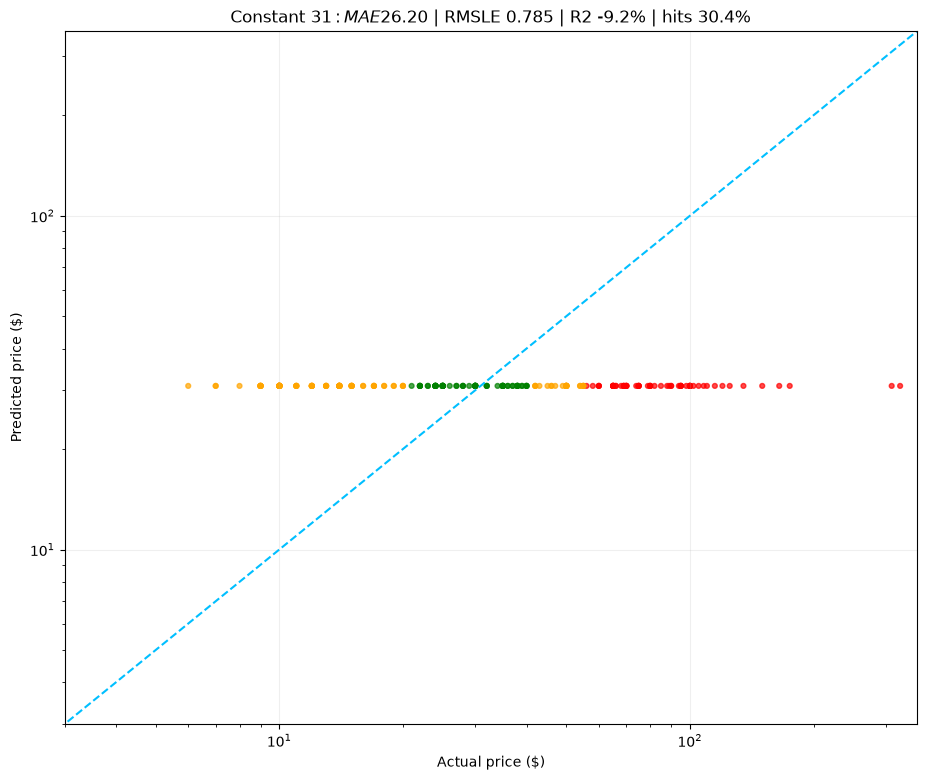

In [2]:
evaluate(constant(train), test)

### Rung 1: metadata only, no tasting note

Country, province, variety, vintage, note length.

Metadata + Linear Regression:   0%|          | 0/250 [00:00<?, ?it/s]

Metadata + Linear Regression: MAE $18.66 | RMSLE 0.537 | R2 32.0% | hits 50.0%


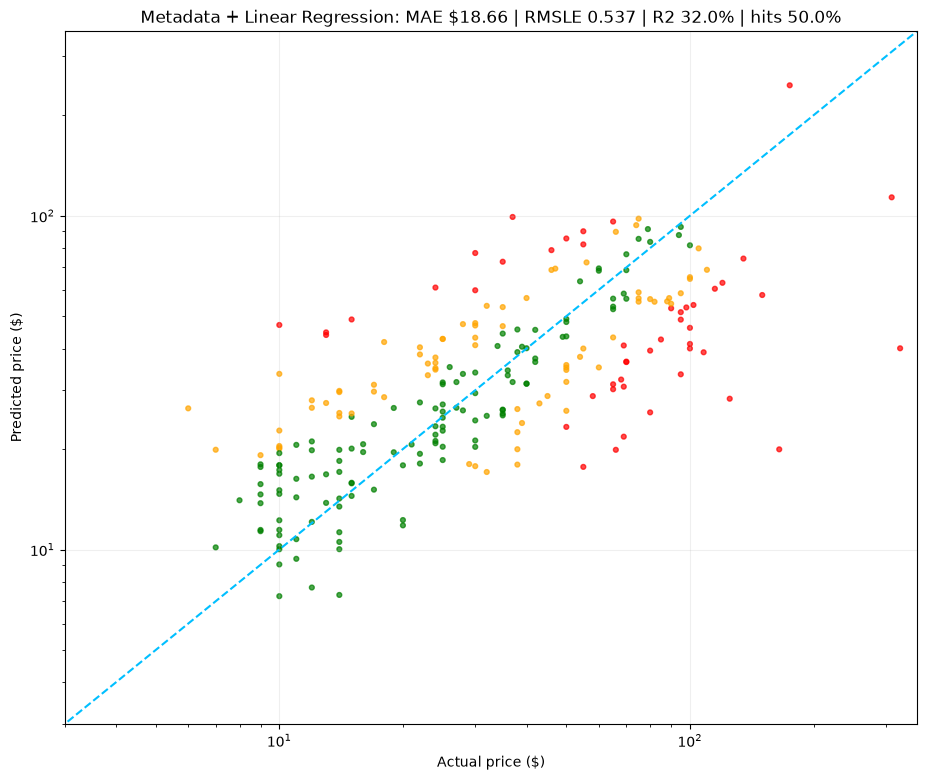

In [3]:
evaluate(metadata_only(train), test)

### Rung 2: the tasting note as bag-of-words

Tf-Idf + Ridge:   0%|          | 0/250 [00:00<?, ?it/s]

Tf-Idf + Ridge: MAE $15.86 | RMSLE 0.454 | R2 47.6% | hits 59.6%


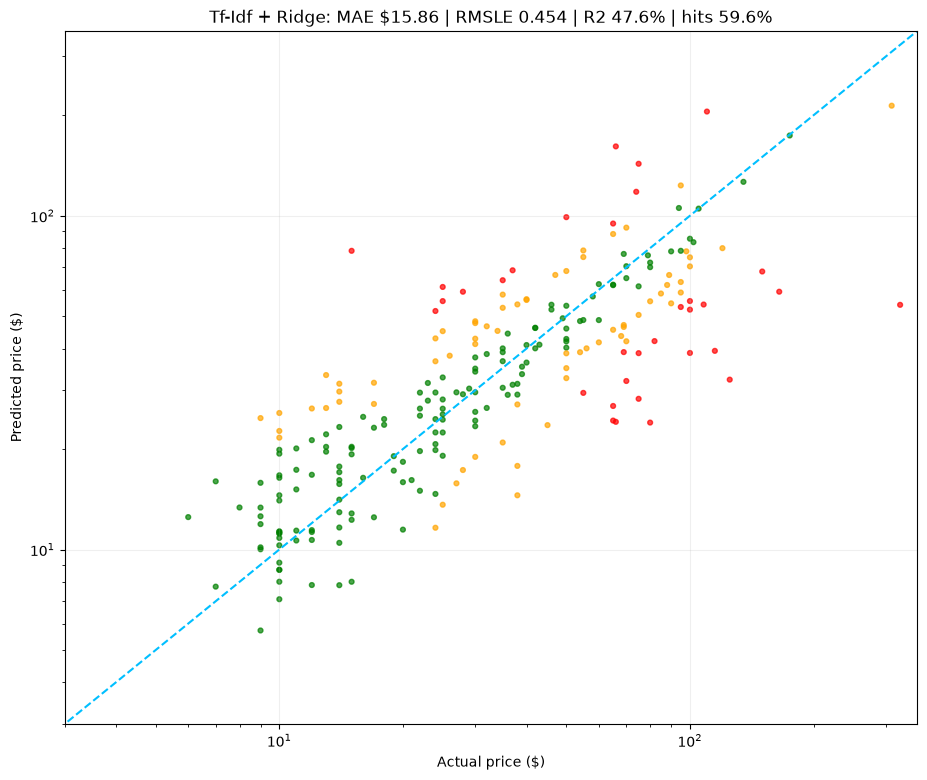

In [4]:
evaluate(tfidf(train), test)

### Rung 3: dense text features into a random forest

Lsa + Random Forest:   0%|          | 0/250 [00:00<?, ?it/s]

Lsa + Random Forest: MAE $17.17 | RMSLE 0.504 | R2 42.5% | hits 52.8%


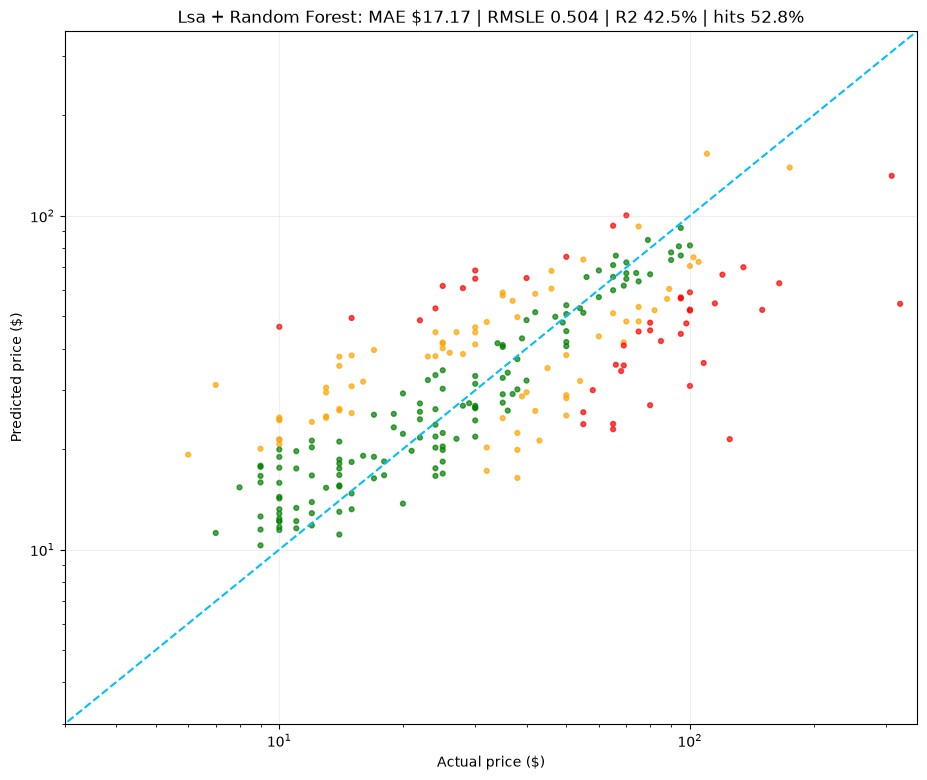

In [5]:
evaluate(lsa_forest(train), test)

In [6]:
leaderboard()

model                                    MAE    RMSLE      R2    hits      n
Frontier (RAG + LLM)                  16.50    0.392-1278.0%   50.0%      2
Tf-Idf + Ridge                        15.86    0.454   47.6%   59.6%    250
TF-IDF + Ridge                        17.09    0.479   44.4%   55.9%  2,000
Lsa + Random Forest                   17.17    0.504   42.5%   52.8%    250
LSA + Random Forest                   18.36    0.527   34.7%   52.9%  2,000
Metadata + Linear Regression          18.66    0.537   32.0%   50.0%    250
Classical (note only)                 21.36    0.548   26.7%   49.0%    100
Neighbours (k=8, retrieval only)      23.94    0.663   11.9%   41.0%    100
Constant $31                          26.20    0.785   -9.2%   30.4%    250


### Which words cost money?

Ridge coefficients on the word features, which double as a sanity check that the model is reading
tasting vocabulary rather than picking up on a scrape artefact.

In [7]:
import numpy as np

model = tfidf(train)
pipeline = model.pipeline
features = pipeline.named_steps["features"]
names = features.get_feature_names_out()
weights = pipeline.named_steps["model"].coef_
order = np.argsort(weights)
print("cheap:")
for index in order[:15]:
    print(f"  {names[index].split('__')[-1]:<24}{weights[index]:+.3f}")
print("expensive:")
for index in order[-15:][::-1]:
    print(f"  {names[index].split('__')[-1]:<24}{weights[index]:+.3f}")

cheap:
  value                   -2.572
  price                   -1.956
  inexpensive             -1.769
  bargain                 -1.753
  affordable              -1.590
  buy                     -1.509
  best buy                -1.469
  ripasso                 -1.366
  chianti                 -1.303
  kabinett                -1.200
  priced                  -1.096
  lodi                    -1.091
  simple                  -1.013
  washington              -0.982
  under 10                -0.981
expensive:
  gaja                    +1.850
  2022                    +1.432
  drink through           +1.423
  amarone                 +1.410
  years                   +1.393
  powerful                +1.347
  cases made              +1.331
  2030                    +1.312
  rancio                  +1.297
  2024                    +1.260
  2025                    +1.239
  2023                    +1.183
  condrieu                +1.171
  hermitage               +1.167
  2026                   

### Experiments worth running here

- Re-curate with `cap=20_000` and see whether the extra cheap wines help or just re-teach the prior.
- Add `points` to the composed text (`pricer.parser.compose`) and measure the jump. That gap is the
  value of the critic score, and a lower bound on how much a model can learn from the note alone.
- Predict `points` instead of price -- same harness, a much less skewed target.
- Swap Ridge for gradient boosting on the LSA features.